# S1 Demo — Data Profiling (Topic 1.2)
Raw Telco churn data → profile → clean → save. **Session 2 trains on the file this notebook saves.**
Runs identically on a laptop and in SageMaker Studio.

In [1]:
import sys, pathlib
p = pathlib.Path.cwd()
while not (p / 'src').exists():
    p = p.parent
sys.path.insert(0, str(p / 'src')); REPO = p
import warnings; warnings.filterwarnings('ignore')

In [2]:
from course_utils import data
df = data.load_raw('telco_churn')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. First look — shapes and types
Spot the smell: `TotalCharges` is `object`, not a number.

In [3]:
data.profile_frame(df)

shape: 7,043 rows x 21 cols | duplicated rows: 0


,dtype,missing,missing_%,unique,sample
customerID,object,0,0.0,7043,7590-VHVEG
gender,object,0,0.0,2,Female
SeniorCitizen,int64,0,0.0,2,0
Partner,object,0,0.0,2,Yes
Dependents,object,0,0.0,2,No
tenure,int64,0,0.0,73,1
PhoneService,object,0,0.0,2,No
MultipleLines,object,0,0.0,3,No phone service
InternetService,object,0,0.0,3,DSL
OnlineSecurity,object,0,0.0,3,No


## 2. The hidden blanks
`TotalCharges` contains spaces masquerading as values — coercion exposes them.

In [4]:
import pandas as pd
tc = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('blank/broken TotalCharges:', tc.isna().sum())
df[tc.isna()][['customerID', 'tenure', 'TotalCharges']].head()

blank/broken TotalCharges: 11


,customerID,tenure,TotalCharges
488,4472-LVYGI,0,
753,3115-CZMZD,0,
936,5709-LVOEQ,0,
1082,4367-NUYAO,0,
1340,1371-DWPAZ,0,


11 rows, all `tenure == 0` (brand-new customers). Decision: **drop** — they carry no churn signal yet. (Imputing 0 is defensible too; the point is to *decide and document*.)

## 3. Class balance — is 73% accuracy good?

Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


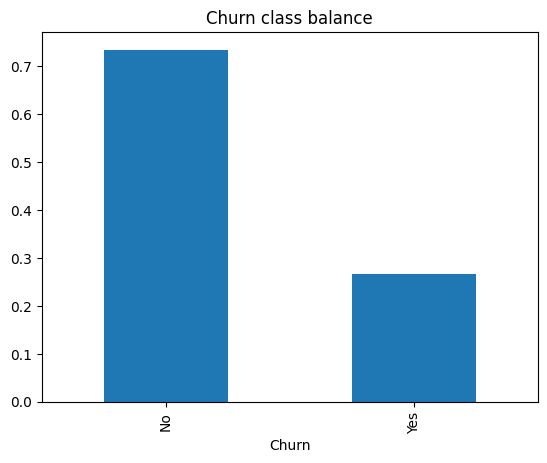

In [5]:
counts = df['Churn'].value_counts(normalize=True)
print(counts.round(3))
counts.plot.bar(title='Churn class balance');

## 4. Distributions & outliers

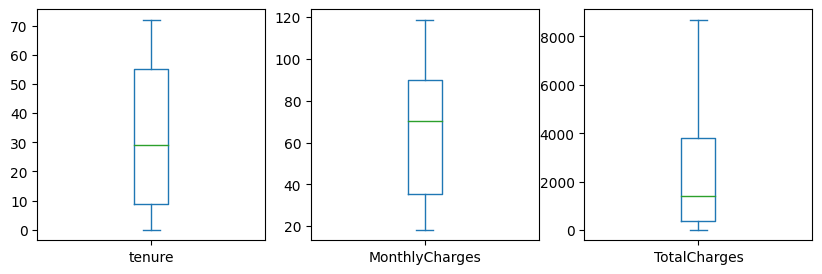

In [6]:
df_num = df.assign(TotalCharges=tc)
df_num[['tenure', 'MonthlyCharges', 'TotalCharges']].plot.box(subplots=True, figsize=(10, 3));

Nothing pathological — *finding nothing is also a result.*

## 5. Clean & save → the pipeline starts here

In [7]:
clean = data.clean_telco(df)
print(clean.shape, '| churn rate:', clean['Churn'].mean().round(3))
data.save_processed(clean, 'telco_clean')

(7032, 20) | churn rate: 0.266
saved -> /Users/dshalvardjiev/claude-cowork/ml-course-syllabus/code-repo/data/processed/telco_clean.parquet


PosixPath('/Users/dshalvardjiev/claude-cowork/ml-course-syllabus/code-repo/data/processed/telco_clean.parquet')